In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/dataset

Mounted at /content/drive
cats  dogs


Mount Drive




#โค้ด 4.1 ทำนายราคาบ้าน
Data Set:
D	Size_sqm	Distance_to_BTS_km	Bedrooms	Price_million_Baht
1	30	0.5	1	3.5
2	45	1.0	1	4.2
3	60	1.5	2	5.5
4	80	2.0	2	6.0
5	100	3.0	3	7.2
6	120	4.0	3	7.5
7	150	5.0	4	9.0

📘 ตัวอย่างข้อมูล:
   Size_sqm  Distance_to_BTS_km  Bedrooms  Price_million_Baht
0        30                 0.5         1                 3.5
1        45                 1.0         1                 4.2
2        60                 1.5         2                 5.5
3        80                 2.0         2                 6.0
4       100                 3.0         3                 7.2
5       120                 4.0         3                 7.5
6       150                 5.0         4                 9.0
7       200                 6.0         5                11.0

📈 สมการ Linear Regression:
Intercept (β₀): 2.191
Coefficients (β): [ 0.02595306 -0.16485404  0.94253005]


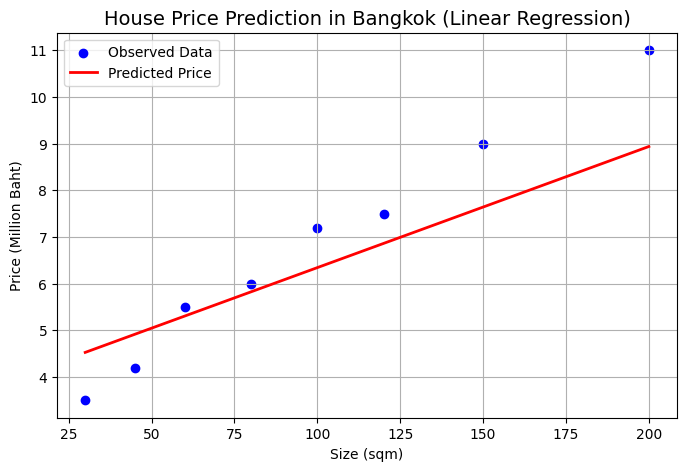


📊 ผลการพยากรณ์ราคาบ้าน:
ขนาด 50 ตร.ม. (1 ห้องนอน, ห่าง BTS 1.5 กม.) → ราคาประมาณ 4.18 ล้านบาท
ขนาด 100 ตร.ม. (2 ห้องนอน, ห่าง BTS 3.0 กม.) → ราคาประมาณ 6.18 ล้านบาท
ขนาด 150 ตร.ม. (3 ห้องนอน, ห่าง BTS 4.0 กม.) → ราคาประมาณ 8.25 ล้านบาท
ขนาด 180 ตร.ม. (4 ห้องนอน, ห่าง BTS 5.0 กม.) → ราคาประมาณ 9.81 ล้านบาท


In [ ]:
# 🔹 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 🔹 สร้างชุดข้อมูลราคาบ้านในเขตกรุงเทพฯ
data = {
    "Size_sqm": [30, 45, 60, 80, 100, 120, 150, 200],
    "Distance_to_BTS_km": [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    "Bedrooms": [1, 1, 2, 2, 3, 3, 4, 5],
    "Price_million_Baht": [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0]
}

df = pd.DataFrame(data)
print("📘 ตัวอย่างข้อมูล:")
print(df)

# 🔹 สร้างโมเดล Linear Regression
X = df[["Size_sqm", "Distance_to_BTS_km", "Bedrooms"]]
y = df["Price_million_Baht"]

model = LinearRegression()
model.fit(X, y)

# 🔹 แสดงค่าสมการ
print("\n📈 สมการ Linear Regression:")
print(f"Intercept (β₀): {model.intercept_:.3f}")
print(f"Coefficients (β): {model.coef_}")

# 🔹 วาดกราฟ
plt.figure(figsize=(8,5))
plt.scatter(df["Size_sqm"], df["Price_million_Baht"], color="blue", label="Observed Data")
plt.plot(size_range, pred_prices, color="red", linewidth=2, label="Predicted Price")
plt.title("House Price Prediction in Bangkok (Linear Regression)", fontsize=14)
plt.xlabel("Size (sqm)")
plt.ylabel("Price (Million Baht)")
plt.legend()
plt.grid(True)
plt.show()

# 🔹 ทดสอบการพยากรณ์ตัวอย่างใหม่
new_data = pd.DataFrame({
    "Size_sqm": [50, 100, 150, 180],
    "Distance_to_BTS_km": [1.5, 3, 4, 5],
    "Bedrooms": [1, 2, 3, 4]
})
pred = model.predict(new_data)

print("\n📊 ผลการพยากรณ์ราคาบ้าน:")
for i in range(len(new_data)):
    print(f"ขนาด {new_data['Size_sqm'][i]} ตร.ม. ({new_data['Bedrooms'][i]} ห้องนอน, ห่าง BTS {new_data['Distance_to_BTS_km'][i]} กม.) → ราคาประมาณ {pred[i]:.2f} ล้านบาท")


#โค้ด 4.2 Random Forest ทำนายราคาบ้าน


📊 ผลการพยากรณ์ราคาบ้าน (ล้านบาท):
   Size_sqm  Distance_to_BTS_km  Bedrooms  Predicted_Price_million_Baht
0        50                 1.5         1                         4.657
1        80                 2.0         2                         5.812
2       100                 3.0         3                         6.909
3       150                 4.5         4                         8.227
4       180                 5.5         4                         9.304

📈 R² = 0.972
📉 RMSE = 0.387 ล้านบาท


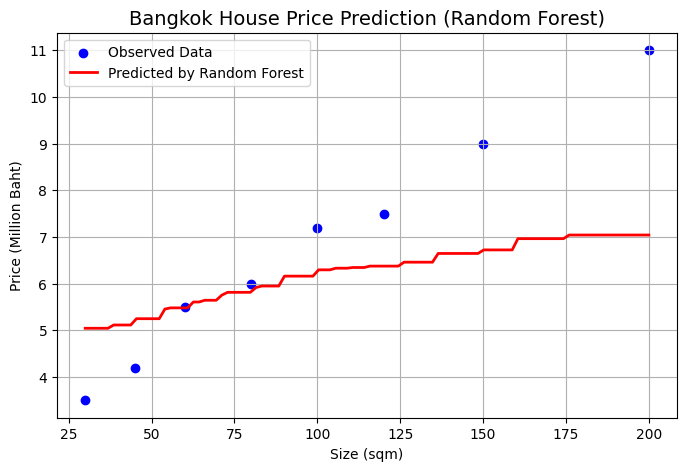

In [ ]:
# ===============================================
# 🌳 Random Forest Regression: Bangkok House Price Prediction
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1. สร้างข้อมูลราคาบ้าน
data = {
    "Size_sqm": [30, 45, 60, 80, 100, 120, 150, 200],
    "Distance_to_BTS_km": [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    "Bedrooms": [1, 1, 2, 2, 3, 3, 4, 5],
    "Price_million_Baht": [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0]
}
df = pd.DataFrame(data)

# 🔹 2. แยก Features และ Target
X = df[["Size_sqm", "Distance_to_BTS_km", "Bedrooms"]]
y = df["Price_million_Baht"]

# 🔹 3. สร้างและฝึกโมเดล Random Forest
model = RandomForestRegressor(
    n_estimators=100,      # จำนวนต้นไม้ในป่า
    max_depth=5,           # ความลึกสูงสุดของแต่ละต้น
    random_state=42
)
model.fit(X, y)

# 🔹 4. ทำนายราคาบ้านใหม่
new_data = pd.DataFrame({
    "Size_sqm": [50, 80, 100, 150, 180],
    "Distance_to_BTS_km": [1.5, 2.0, 3.0, 4.5, 5.5],
    "Bedrooms": [1, 2, 3, 4, 4]
})
pred = model.predict(new_data)
new_data["Predicted_Price_million_Baht"] = pred

# 🔹 5. แสดงผลลัพธ์
print("📊 ผลการพยากรณ์ราคาบ้าน (ล้านบาท):")
print(new_data)

# 🔹 6. ประเมินประสิทธิภาพโมเดล
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"\n📈 R² = {r2:.3f}")
print(f"📉 RMSE = {rmse:.3f} ล้านบาท")

# 🔹 7. วาดกราฟ: ขนาดบ้าน vs ราคาที่ทำนายได้
size_range = np.linspace(30, 200, 100)
pred_prices = model.predict(pd.DataFrame({
    "Size_sqm": size_range,
    "Distance_to_BTS_km": np.full(100, 2),
    "Bedrooms": np.full(100, 2)
}))

plt.figure(figsize=(8,5))
plt.scatter(df["Size_sqm"], df["Price_million_Baht"], color="blue", label="Observed Data")
plt.plot(size_range, pred_prices, color="red", linewidth=2, label="Predicted by Random Forest")
plt.title("Bangkok House Price Prediction (Random Forest)", fontsize=14)
plt.xlabel("Size (sqm)")
plt.ylabel("Price (Million Baht)")
plt.legend()
plt.grid(True)
plt.show()


# โค้ด 4.3 Logistic Regression ทำนายระดับราคาบ้าน (Low / Medium / High)

📊 ตารางข้อมูลราคาบ้าน (แบ่ง 3 กลุ่ม):
   Size_sqm  Distance_to_BTS_km  Bedrooms  Price_million_Baht Price_Class  \
0        30                 0.5         1                 3.5         Low   
1        45                 1.0         1                 4.2         Low   
2        60                 1.5         2                 5.5         Low   
3        80                 2.0         2                 6.0      Medium   
4       100                 3.0         3                 7.2      Medium   
5       120                 4.0         3                 7.5      Medium   
6       150                 5.0         4                 9.0        High   
7       200                 6.0         5                11.0        High   

   Price_Label  
0            1  
1            1  
2            1  
3            2  
4            2  
5            2  
6            0  
7            0  

📈 ผลการพยากรณ์ราคาบ้าน:
   Size_sqm  Price_million_Baht Price_Class Predicted_Class
0        30                 3.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


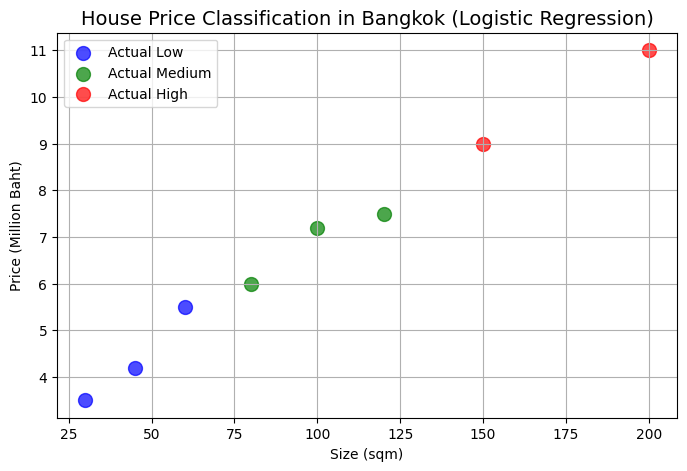

In [ ]:
# ===============================================
# 🏠 Logistic Regression วิเคราะห์ระดับราคาบ้านในเขตกรุงเทพฯ
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 🔹 1. สร้างชุดข้อมูลราคาบ้านในเขตกรุงเทพฯ
data = {
    "Size_sqm": [30, 45, 60, 80, 100, 120, 150, 200],
    "Distance_to_BTS_km": [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    "Bedrooms": [1, 1, 2, 2, 3, 3, 4, 5],
    "Price_million_Baht": [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0]
}

df = pd.DataFrame(data)

# 🔹 2. สร้างฟังก์ชันแบ่งกลุ่มราคา
def classify_price(price):
    if price < 6:
        return "Low"
    elif 6 <= price <= 8:
        return "Medium"
    else:
        return "High"

df["Price_Class"] = df["Price_million_Baht"].apply(classify_price)

# 🔹 3. แปลง Label เป็นตัวเลข ( เช่น High=0, Low=1, Medium=2 ) เรียงตามอักษร
le = LabelEncoder()
df["Price_Label"] = le.fit_transform(df["Price_Class"])

# แสดงข้อมูล
print("📊 ตารางข้อมูลราคาบ้าน (แบ่ง 3 กลุ่ม):")
print(df)

# 🔹 4. แยก Features (X) และ Target (y)
X = df[["Size_sqm", "Distance_to_BTS_km", "Bedrooms"]]
y = df["Price_Label"]

# 🔹 5. สร้างโมเดล Logistic Regression แบบหลายคลาส (Multinomial)
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)
model.fit(X, y)

# 🔹 6. พยากรณ์กลุ่มราคาบ้าน
df["Predicted_Label"] = model.predict(X)
df["Predicted_Class"] = le.inverse_transform(df["Predicted_Label"])

# 🔹 7. แสดงตารางผลลัพธ์
print("\n📈 ผลการพยากรณ์ราคาบ้าน:")
print(df[["Size_sqm", "Price_million_Baht", "Price_Class", "Predicted_Class"]])

# 🔹 8. ประเมินประสิทธิภาพโมเดล
print("\n📊 Classification Report:")
print(classification_report(y, df["Predicted_Label"], target_names=le.classes_))

# 🔹 9. สร้าง Confusion Matrix
conf_mat = confusion_matrix(y, df["Predicted_Label"])
print("\n🧮 Confusion Matrix:")
print(conf_mat)

# 🔹 10. วาดกราฟแสดงผล
colors = {"Low": "blue", "Medium": "green", "High": "red"}
plt.figure(figsize=(8,5))
for label in colors:
    subset = df[df["Price_Class"] == label]
    plt.scatter(subset["Size_sqm"], subset["Price_million_Baht"],
                color=colors[label], label=f"Actual {label}", s=100, alpha=0.7)

plt.title("House Price Classification in Bangkok (Logistic Regression)", fontsize=14)
plt.xlabel("Size (sqm)")
plt.ylabel("Price (Million Baht)")
plt.legend()
plt.grid(True)
plt.show()


#โค้ด 4.4 Decision Tree จำแนกกลุ่มบ้าน

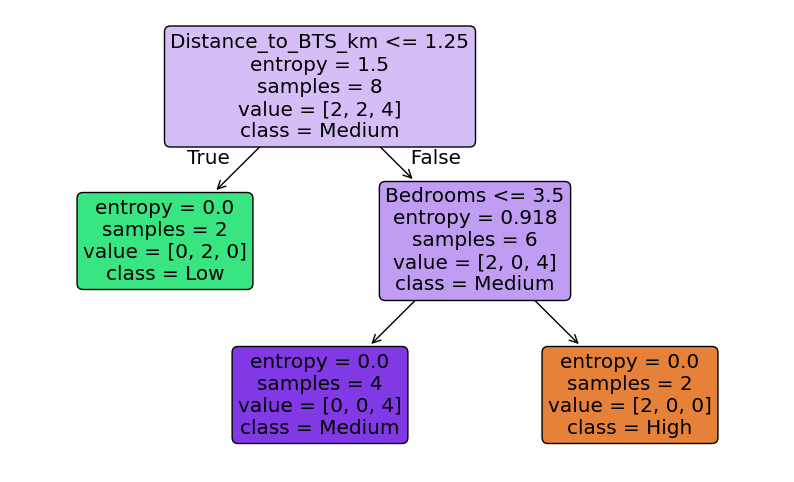

Predicted class: Medium


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# 1. Prepare dataset
# -----------------------------
data = {
    'Size_sqm': [30, 45, 60, 80, 100, 120, 150, 200],
    'Distance_to_BTS_km': [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    'Bedrooms': [1, 1, 2, 2, 3, 3, 4, 5],
    'Class': ['Low', 'Low', 'Medium', 'Medium', 'Medium', 'Medium', 'High', 'High']
}

df = pd.DataFrame(data)

# Separate features (X) and target (y)
X = df[['Size_sqm', 'Distance_to_BTS_km', 'Bedrooms']]
y = df['Class']

# -----------------------------
# 2. Train the Decision Tree model
# -----------------------------
model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)

# -----------------------------
# 3. Visualize the decision tree
# -----------------------------
plt.figure(figsize=(10,6))
plot_tree(model,
          feature_names=['Size_sqm', 'Distance_to_BTS_km', 'Bedrooms'],
          class_names=model.classes_,
          filled=True,
          rounded=True)
plt.show()

# -----------------------------
# 4. Make a prediction example
# -----------------------------
# Predict for a new house
new_house = [[90, 2.5, 2]]  # 90 sqm, 2.5 km, 2 bedrooms
prediction = model.predict(new_house)
print("Predicted class:", prediction[0])

#โค้ด 4.5 Random Forest Classification

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


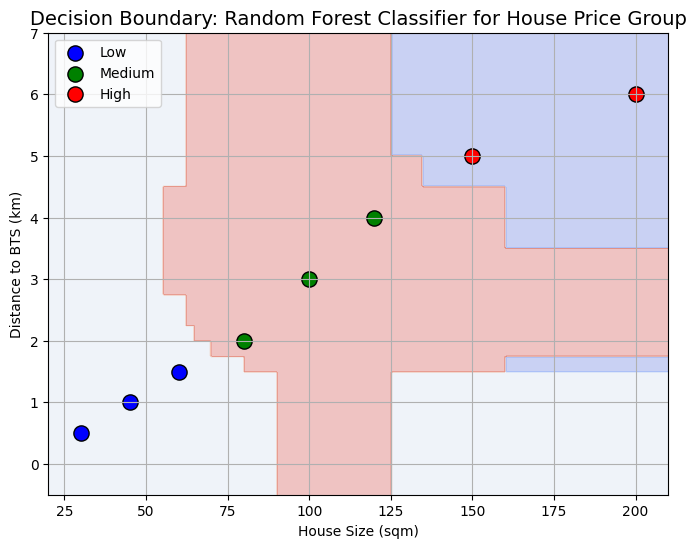

In [2]:
# ===============================================
# 🌳 Random Forest Classifier + Decision Boundary Visualization
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 🔹 1. สร้างข้อมูลราคาบ้าน
data = {
    "Size_sqm": [30, 45, 60, 80, 100, 120, 150, 200],
    "Distance_to_BTS_km": [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    "Bedrooms": [1, 1, 2, 2, 3, 3, 4, 5],
    "Price_million_Baht": [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0]
}
df = pd.DataFrame(data)

# 🔹 2. แบ่งกลุ่มราคา
def classify_price(price):
    if price < 6:
        return "Low"
    elif 6 <= price <= 8:
        return "Medium"
    else:
        return "High"

df["Price_Class"] = df["Price_million_Baht"].apply(classify_price)

# 🔹 3. แปลง Label เป็นตัวเลข
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Price_Class"])

# 🔹 4. ใช้เพียง 2 ตัวแปรเพื่อให้วาดกราฟได้ (Size, Distance)
X = df[["Size_sqm", "Distance_to_BTS_km"]]
y = df["Label"]

# 🔹 5. สร้างโมเดล Random Forest Classifier
model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X, y)

# 🔹 6. สร้าง Grid สำหรับวาด Decision Boundary
x_min, x_max = X["Size_sqm"].min() - 10, X["Size_sqm"].max() + 10
y_min, y_max = X["Distance_to_BTS_km"].min() - 1, X["Distance_to_BTS_km"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 🔹 7. สีของแต่ละกลุ่ม
colors = {"Low": "blue", "Medium": "green", "High": "red"}

# 🔹 8. วาดกราฟ Decision Boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# วาดจุดข้อมูลจริง
for label in colors:
    subset = df[df["Price_Class"] == label]
    plt.scatter(subset["Size_sqm"], subset["Distance_to_BTS_km"],
                color=colors[label], label=label, s=120, edgecolor='k')

plt.title("Decision Boundary: Random Forest Classifier for House Price Group", fontsize=14)
plt.xlabel("House Size (sqm)")
plt.ylabel("Distance to BTS (km)")
plt.legend()
plt.grid(True)
plt.show()


In [3]:

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance
0            Size_sqm    0.532908
1  Distance_to_BTS_km    0.467092


#โค้ด 4.6 AI Assistant หาบ้าน


In [ ]:
# ===============================================
# 🌳 Random Forest Decision Assistant for House Selection
# ===============================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 🔹 1. สร้างข้อมูลตัวอย่างบ้าน
data = {
    "House_ID": [1, 2, 3, 4, 5, 6, 7, 8],
    "Size_sqm": [18, 25, 30, 45, 60, 80, 100, 120],
    "Bedrooms": [1, 2, 2, 3, 3, 4, 4, 5],
    "Price_million": [0.8, 1.0, 1.5, 2.0, 2.5, 3.0, 4.5, 5.0]
}
df = pd.DataFrame(data)

# 🔹 2. แบ่งราคาบ้านเป็น 3 กลุ่ม
def classify_price(price):
    if price <= 1.0:
        return "Cheap"
    elif 1.0 < price <= 2.0:
        return "Medium"
    else:
        return "Expensive"

df["Price_Class"] = df["Price_million"].apply(classify_price)

# 🔹 3. เตรียมข้อมูลสำหรับโมเดล
X = df[["Size_sqm", "Bedrooms"]]
y = df["Price_Class"]

le = LabelEncoder()
df["Label"] = le.fit_transform(y)

# 🔹 4. สร้างและฝึกโมเดล Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, df["Label"])

# 🔹 5. กำหนด Spec ของคุณ
spec = {"min_size": 20, "min_bedroom": 2}

# 🔹 6. กรองบ้านตาม Spec
filtered = df[(df["Size_sqm"] >= spec["min_size"]) & (df["Bedrooms"] >= spec["min_bedroom"])]

# 🔹 7. ทำนายกลุ่มราคา (จำแนกใหม่)
filtered["Predicted_Label"] = model.predict(filtered[["Size_sqm", "Bedrooms"]])
filtered["Predicted_Class"] = le.inverse_transform(filtered["Predicted_Label"])

# 🔹 8. แสดงบ้านที่ผ่านเกณฑ์ พร้อมคำแนะนำ
print("🏡 บ้านที่ตรงตาม Spec ของคุณ:")
print(filtered[["House_ID", "Size_sqm", "Bedrooms", "Price_million", "Predicted_Class"]])

# 🔹 9. แนะนำบ้านที่ “ราคาถูกที่สุดในกลุ่มที่ตรง Spec”
best = filtered[filtered["Predicted_Class"] == "Cheap"].sort_values("Price_million").head(1)
if not best.empty:
    print("\n✅ บ้านที่เหมาะสมที่สุดสำหรับคุณคือ:")
    print(best[["House_ID", "Size_sqm", "Bedrooms", "Price_million"]])
else:
    print("\n⚠️ ไม่มีบ้านราคาถูกตาม Spec ของคุณ")


🏡 บ้านที่ตรงตาม Spec ของคุณ:
   House_ID  Size_sqm  Bedrooms  Price_million Predicted_Class
1         2        25         2            1.0           Cheap
2         3        30         2            1.5          Medium
3         4        45         3            2.0          Medium
4         5        60         3            2.5       Expensive
5         6        80         4            3.0       Expensive
6         7       100         4            4.5       Expensive
7         8       120         5            5.0       Expensive

✅ บ้านที่เหมาะสมที่สุดสำหรับคุณคือ:
   House_ID  Size_sqm  Bedrooms  Price_million
1         2        25         2            1.0


/tmp/ipython-input-1400707186.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["Predicted_Label"] = model.predict(filtered[["Size_sqm", "Bedrooms"]])
/tmp/ipython-input-1400707186.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["Predicted_Class"] = le.inverse_transform(filtered["Predicted_Label"])


#โค้ด 4.7 K-Nearest Neighbor จัดกลุ่มบ้าน k=3

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


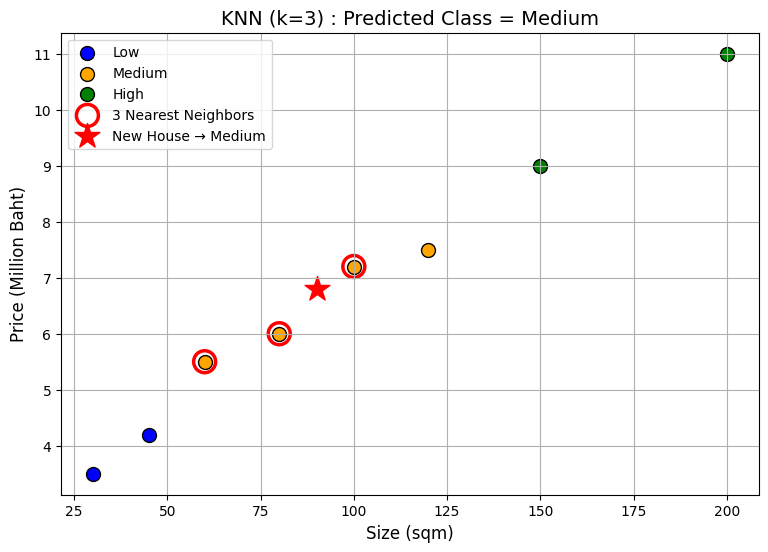

In [ ]:
# ==============================================
# 🏠 KNN Classifier for House Price Classification (k=3)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# 1️⃣ เตรียมข้อมูล
# -----------------------------
data = {
    'Size': [30, 45, 60, 80, 100, 120, 150, 200],
    'Distance': [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    'Bedrooms': [1, 1, 2, 2, 3, 3, 4, 5],
    'Price': [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0],
    'Class': ['Low', 'Low', 'Medium', 'Medium', 'Medium', 'Medium', 'High', 'High']
}
df = pd.DataFrame(data)

# -----------------------------
# 2️⃣ แยก Features และ Target
# -----------------------------
X = df[['Size', 'Distance', 'Bedrooms', 'Price']]
y = df['Class']

# -----------------------------
# 3️⃣ สร้างโมเดล KNN (k=3)
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# -----------------------------
# 4️⃣ ทำนายบ้านใหม่
# -----------------------------
new_house = [[90, 2.5, 2, 6.8]]  # บ้านใหม่
pred = knn.predict(new_house)

# -----------------------------
# 5️⃣ หาค่าระยะทางของเพื่อนบ้าน
# -----------------------------
distances, indices = knn.kneighbors(new_house)

# -----------------------------
# 6️⃣ วาดกราฟ (Size vs Price)
# -----------------------------
plt.figure(figsize=(9, 6))
colors = {'Low': 'blue', 'Medium': 'orange', 'High': 'green'}

# วาดจุดบ้านทั้งหมด
for c in colors:
    subset = df[df['Class'] == c]
    plt.scatter(subset['Size'], subset['Price'],
                color=colors[c], s=100, edgecolors='black', label=c)

# วาดวงกลมรอบเพื่อนบ้านที่ใกล้สุด
plt.scatter(df.iloc[indices[0]]['Size'], df.iloc[indices[0]]['Price'],
            s=250, facecolors='none', edgecolors='red', linewidth=2.5, label='3 Nearest Neighbors')

# วาดบ้านใหม่ (ที่ต้องการทำนาย)
plt.scatter(new_house[0][0], new_house[0][3],
            color='red', marker='*', s=350, label=f'New House → {pred[0]}')

# ตั้งค่ากราฟ
plt.title(f'KNN (k=3) : Predicted Class = {pred[0]}', fontsize=14)
plt.xlabel('Size (sqm)', fontsize=12)
plt.ylabel('Price (Million Baht)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#โค้ด 4.8 K-Means จัดกลุ่มบ้าน

Centroids (ค่าเฉลี่ยของแต่ละกลุ่ม):
Cluster 1: Size=100.0, Distance=3.0, Bedrooms=2.7, Price=6.9
Cluster 2: Size=175.0, Distance=5.5, Bedrooms=4.5, Price=10.0
Cluster 3: Size=45.0, Distance=1.0, Bedrooms=1.3, Price=4.4

ข้อมูลแต่ละบ้านพร้อมกลุ่มที่อยู่:
   Size  Distance  Bedrooms  Price  Cluster
0    30       0.5         1    3.5        2
1    45       1.0         1    4.2        2
2    60       1.5         2    5.5        2
3    80       2.0         2    6.0        0
4   100       3.0         3    7.2        0
5   120       4.0         3    7.5        0
6   150       5.0         4    9.0        1
7   200       6.0         5   11.0        1


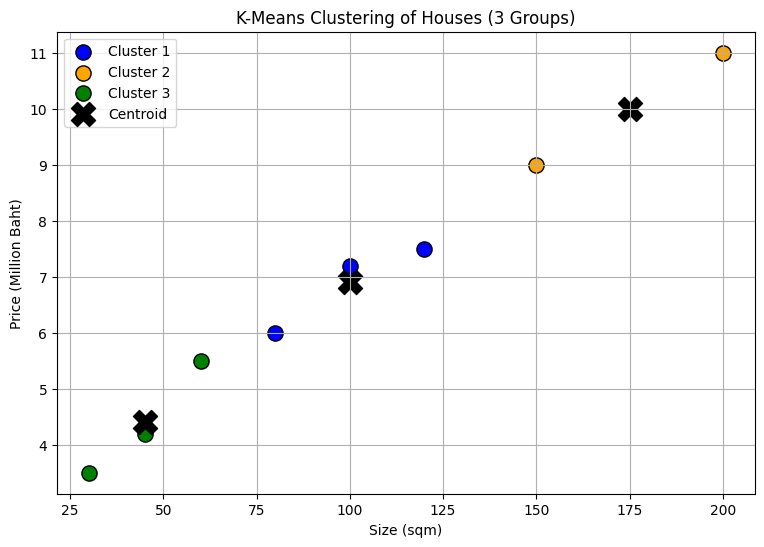

In [ ]:
# ==========================================
# 🏠 K-Means Clustering: House Grouping Example
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -----------------------------
# 1️⃣ เตรียมข้อมูลบ้าน
# -----------------------------
data = {
    'Size': [30, 45, 60, 80, 100, 120, 150, 200],
    'Distance': [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
    'Bedrooms': [1, 1, 2, 2, 3, 3, 4, 5],
    'Price': [3.5, 4.2, 5.5, 6.0, 7.2, 7.5, 9.0, 11.0]
}

df = pd.DataFrame(data)

# -----------------------------
# 2️⃣ ใช้ K-Means แบ่งข้อมูลเป็น 3 กลุ่ม
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Size', 'Distance', 'Bedrooms', 'Price']])
centroids = kmeans.cluster_centers_

# -----------------------------
# 3️⃣ แสดงผลลัพธ์
# -----------------------------
print("Centroids (ค่าเฉลี่ยของแต่ละกลุ่ม):")
for i, c in enumerate(centroids):
    print(f"Cluster {i+1}: Size={c[0]:.1f}, Distance={c[1]:.1f}, Bedrooms={c[2]:.1f}, Price={c[3]:.1f}")

print("\nข้อมูลแต่ละบ้านพร้อมกลุ่มที่อยู่:")
print(df)

# -----------------------------
# 4️⃣ วาดกราฟ Size vs Price
# -----------------------------
plt.figure(figsize=(9, 6))
colors = ['blue', 'orange', 'green']

for cluster_id, color in enumerate(colors):
    cluster_points = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_points['Size'], cluster_points['Price'],
                color=color, s=120, edgecolor='black', label=f'Cluster {cluster_id + 1}')

# วาดจุด centroid
plt.scatter(centroids[:, 0], centroids[:, 3],
            marker='X', s=300, color='black', label='Centroid')

# ตั้งชื่อกราฟ
plt.title('K-Means Clustering of Houses (3 Groups)')
plt.xlabel('Size (sqm)')
plt.ylabel('Price (Million Baht)')
plt.legend()
plt.grid(True)
plt.show()

#โค้ด 4.9 DBSCANS สำหรับจัดกลุ่มบ้านตามพิกัด X,Y

  Home     X    Y  Cluster
0   H1   1.0  1.2        0
1   H2   1.2  1.3        0
2   H3   1.3  1.4        0
3   H4   5.5  5.8        1
4   H5   5.6  5.9        1
5   H6   9.8  9.6        2
6   H7   9.9  9.7        2
7   H8  10.1  9.8        2
8   H9  12.0  1.0       -1


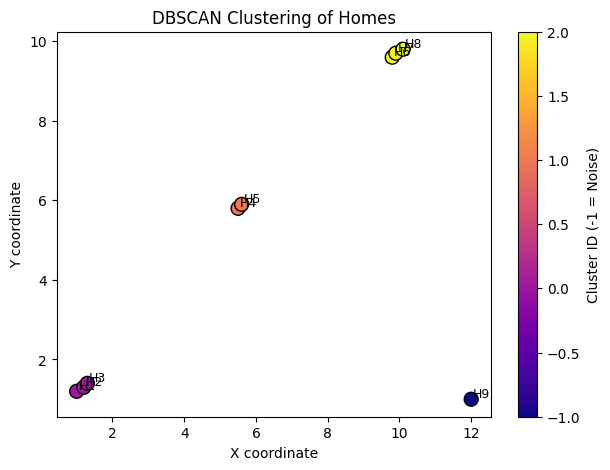

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# -------------------------
# 1. Create the data
# -------------------------
data = {
    'Home': ['H1','H2','H3','H4','H5','H6','H7','H8','H9'],
    'X': [1.0, 1.2, 1.3, 5.5, 5.6, 9.8, 9.9, 10.1, 12.0],
    'Y': [1.2, 1.3, 1.4, 5.8, 5.9, 9.6, 9.7, 9.8, 1.0]
}
df = pd.DataFrame(data)

# Features for clustering
X = df[['X', 'Y']].values

# -------------------------
# 2. Run DBSCAN
# -------------------------
# eps = 0.5 (radius), min_samples = 2 (MinPts)
db = DBSCAN(eps=0.5, min_samples=2).fit(X)

# Add cluster labels back to DataFrame
df['Cluster'] = db.labels_

# -------------------------
# 3. Display results
# -------------------------
print(df)

# -------------------------
# 4. Plot the clusters
# -------------------------
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=db.labels_, cmap='plasma', s=100, edgecolors='k')

# Label points
for i, txt in enumerate(df['Home']):
    plt.annotate(txt, (X[i,0]+0.05, X[i,1]+0.05), fontsize=9)

plt.title("DBSCAN Clustering of Homes")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.colorbar(label='Cluster ID (-1 = Noise)')
plt.show()

#โค้ด 4.10 PCA ข้อมูลสุขภาพ

🔹 ข้อมูลเริ่มต้น
   BloodPressure  Glucose  BMI  HeartRate  Cholesterol
0            140      180   29         90          240
1            130      160   27         80          220
2            110      120   22         70          180
3            150      190   31         95          250
4            125      150   24         75          200
5            135      170   26         85          230
6            145      185   30         92          245
7            120      130   23         72          190

🔹 ผลลัพธ์หลังทำ PCA:
        PC1       PC2
0  1.763375  0.031142
1 -0.115572  0.141973
2 -3.514070  0.211103
3  3.024320  0.156982
4 -1.520518 -0.240532
5  0.539501 -0.433809
6  2.368768  0.088679
7 -2.545804  0.044463


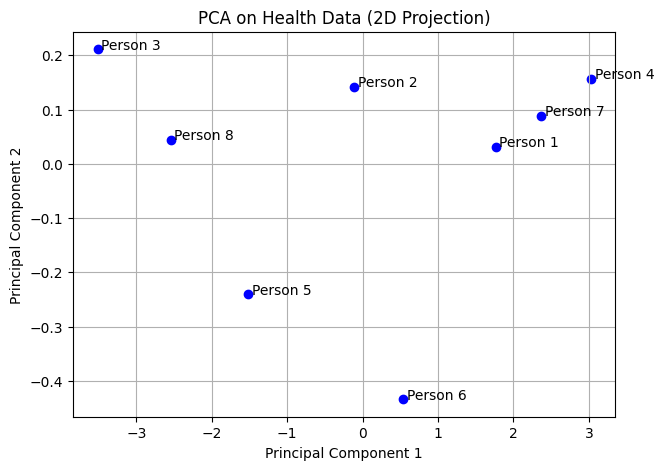


🔹 สัดส่วนความแปรปรวนที่อธิบายได้โดยแต่ละแกน:
[0.98283166 0.00865553]
[[ 0.44761753  0.44738756  0.44401998  0.44789503  0.44913163]
 [-0.19707405 -0.50007102  0.81242239  0.09612729 -0.20449987]]


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ สร้างข้อมูลสุขภาพจำลอง
# -----------------------------
data = {
    'BloodPressure': [140, 130, 110, 150, 125, 135, 145, 120],
    'Glucose': [180, 160, 120, 190, 150, 170, 185, 130],
    'BMI': [29, 27, 22, 31, 24, 26, 30, 23],
    'HeartRate': [90, 80, 70, 95, 75, 85, 92, 72],
    'Cholesterol': [240, 220, 180, 250, 200, 230, 245, 190]
}

df = pd.DataFrame(data)
print("🔹 ข้อมูลเริ่มต้น")
print(df)

# -----------------------------
# 2️⃣ มาตรฐานข้อมูล (Standardization)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -----------------------------
# 3️⃣ ทำ PCA ให้เหลือ 2 มิติ
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 4️⃣ แสดงผลลัพธ์ PCA
# -----------------------------
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print("\n🔹 ผลลัพธ์หลังทำ PCA:")
print(pca_df)

# -----------------------------
# 5️⃣ วาดกราฟแสดงผล
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='blue')
for i, txt in enumerate(df.index):
    plt.annotate(f'Person {i+1}', (pca_df['PC1'][i]+0.05, pca_df['PC2'][i]))
plt.title('PCA on Health Data (2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# -----------------------------
# 6️⃣ ตรวจสอบสัดส่วนความแปรปรวนที่อธิบายได้
# -----------------------------
print("\n🔹 สัดส่วนความแปรปรวนที่อธิบายได้โดยแต่ละแกน:")
print(pca.explained_variance_ratio_)
print(pca.components_)


แสดงคอลัมน์ใน PC1

In [ ]:
import pandas as pd

# Assuming 'pca' and 'df' from the previous cell bgbpX1i1EsJl are available in the kernel.

# Define 'loadings' as a DataFrame for better readability and to match the 'PC1' access pattern.
# The column names for loadings correspond to the original features.
feature_names = df.columns
loadings = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])

print("Loadings for PC1:")
print(loadings.loc['PC1'])


Loadings for PC1:
BloodPressure    0.447618
Glucose          0.447388
BMI              0.444020
HeartRate        0.447895
Cholesterol      0.449132
Name: PC1, dtype: float64


#โค้ด 4.11 LDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1. สร้างข้อมูลจำลองลูกค้า
# -----------------------------
data = {
    'Age': [22, 25, 47, 52, 46, 56, 55, 60, 23, 34, 45, 52, 36, 29, 41, 57, 31, 49, 40, 50],
    'Income': [20000, 25000, 70000, 90000, 80000, 120000, 110000, 130000, 22000, 40000,
               60000, 85000, 42000, 30000, 58000, 125000, 35000, 75000, 55000, 95000],
    'Web_Visits': [5, 7, 2, 1, 2, 0, 1, 0, 5, 4, 3, 2, 4, 6, 3, 1, 4, 2, 3, 1],
    'Purchased': [0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
}
df = pd.DataFrame(data)

# -----------------------------
# 2. แบ่งข้อมูล Train/Test
# -----------------------------
X = df[['Age', 'Income']]
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 3. สร้างและฝึกโมเดล LDA
# -----------------------------
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# -----------------------------
# 4. ทำนายผลและประเมินความแม่นยำ
# -----------------------------
y_pred = lda.predict(X_test)
print("🎯 Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 5. ทำนายลูกค้าใหม่
# -----------------------------
new_customer = pd.DataFrame({
    'Age': [30, 55, 42],
    'Income': [35000, 115000, 65000]
})
prediction = lda.predict(new_customer)
print("\n🧮 New Customer Predictions:")
for i, pred in enumerate(prediction):
    label = "✅ Purchased" if pred == 1 else "❌ Not Purchased"
    print(f"Customer {i+1}: {label}")

# -----------------------------
# 6. สร้างตาราง meshgrid สำหรับกราฟ
# -----------------------------
x_min, x_max = X['Age'].min() - 2, X['Age'].max() + 2
y_min, y_max = X['Income'].min() - 5000, X['Income'].max() + 5000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -----------------------------
# 7. วาดกราฟ Decision Boundary
# -----------------------------
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# ข้อมูลจริง
plt.scatter(X['Age'][y == 0], X['Income'][y == 0],
            color='red', edgecolor='k', marker='o', s=100, label='Not Purchased (0)')
plt.scatter(X['Age'][y == 1], X['Income'][y == 1],
            color='blue', edgecolor='k', marker='^', s=100, label='Purchased (1)')

# ลูกค้าใหม่
plt.scatter(new_customer['Age'], new_customer['Income'],
            color='gold', edgecolor='black', marker='*', s=300, label='New Customer')

# เส้นจำแนก
coef = lda.coef_[0]
intercept = lda.intercept_[0]
x_vals = np.linspace(x_min, x_max, 100)
y_vals = -(coef[0] * x_vals + intercept) / coef[1]
plt.plot(x_vals, y_vals, color='black', linewidth=2.5, label='LDA Decision Line')

# -----------------------------
# 8. ตกแต่งกราฟ
# -----------------------------
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.title("LDA Decision Boundary with Prediction", fontsize=14, weight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#โค้ด 4.12 Apriori

In [ ]:
!pip install mlxtend --quiet


Transaction Matrix:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ขนมปัง,นม,น้ำตาล,เนย,ไข่
0,True,True,False,True,False
1,True,False,True,False,False
2,True,True,True,True,False
3,True,True,False,False,False
4,False,False,True,True,False
5,True,False,False,True,True
6,True,True,True,False,False
7,False,True,True,False,False



Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

from matplotlib import pyplot as plt
frequent_itemsets['support'].plot(kind='hist', bins=20, title='support')
plt.gca().spines[['top', 'right',]].set_visible(False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

from matplotlib import pyplot as plt
frequent_itemsets['support'].plot(kind='line', figsize=(8, 4), title='support')
plt.gca().spines[['top', 'right']].set_visible(False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#โค้ด 4.12 FP-GROWTH

In [ ]:
pip install mlxtend

In [ ]:
# -------------------------------
# 🔹 ตัวอย่าง FP-Growth สำหรับระบบแนะนำสินค้า
# -------------------------------
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1️⃣ ข้อมูลธุรกรรม (transactions)
dataset = [
    ['นม', 'ขนมปัง', 'เนย'],
    ['ขนมปัง', 'น้ำตาล'],
    ['ขนมปัง', 'เนย', 'น้ำตาล', 'นม'],
    ['นม', 'ขนมปัง'],
    ['น้ำตาล', 'เนย'],
    ['ขนมปัง', 'เนย', 'ไข่'],
    ['นม', 'ขนมปัง', 'น้ำตาล'],
    ['น้ำตาล', 'นม']
]

# 2️⃣ แปลงข้อมูลให้อยู่ในรูปที่ FP-Growth ใช้ได้
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("🔹 ตัวอย่างข้อมูลหลังแปลงเป็นตาราง:")
print(df.head())

# 3️⃣ หาชุดสินค้าที่เกิดร่วมกันบ่อย (Frequent Itemsets)
frequent_itemsets = fpgrowth(df, min_support=0.25, use_colnames=True)
print("\n🔹 Frequent Itemsets ที่พบ:")
print(frequent_itemsets)

# 4️⃣ สร้างกฎความสัมพันธ์ (Association Rules)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print("\n🔹 กฎความสัมพันธ์ที่ได้:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# 5️⃣ เรียงกฎตามค่า Lift (ยิ่งสูงยิ่งสัมพันธ์กันมาก)
rules = rules.sort_values(by='lift', ascending=False)
print("\n🔹 เรียงตามค่า Lift สูงสุด:")
print(rules[['antecedents', 'consequents', 'lift']].head())


🔹 ตัวอย่างข้อมูลหลังแปลงเป็นตาราง:
   ขนมปัง     นม  น้ำตาล    เนย    ไข่
0    True   True   False   True  False
1    True  False    True  False  False
2    True   True    True   True  False
3    True   True   False  False  False
4   False  False    True   True  False

🔹 Frequent Itemsets ที่พบ:
    support              itemsets
0     0.750              (ขนมปัง)
1     0.625                  (นม)
2     0.500                 (เนย)
3     0.625              (น้ำตาล)
4     0.500          (ขนมปัง, นม)
5     0.375          (น้ำตาล, นม)
6     0.250  (ขนมปัง, น้ำตาล, นม)
7     0.375         (ขนมปัง, เนย)
8     0.250             (เนย, นม)
9     0.250         (เนย, น้ำตาล)
10    0.250     (ขนมปัง, เนย, นม)
11    0.375      (ขนมปัง, น้ำตาล)

🔹 กฎความสัมพันธ์ที่ได้:
        antecedents consequents  support  confidence      lift
0          (ขนมปัง)        (นม)    0.500    0.666667  1.066667
1              (นม)    (ขนมปัง)    0.500    0.800000  1.066667
2          (น้ำตาล)        (นม)    0.375    0.6

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#LSTM stock'

In [ ]:
import os

# Download TA-Lib C library
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzf ta-lib-0.4.0-src.tar.gz

# Install TA-Lib C library
os.chdir('ta-lib/')
!./configure --prefix=/usr
!make
!sudo make install

# Install the Python wrapper for TA-Lib
!pip install ta-lib

--2025-11-12 16:59:15--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:d95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2025-11-12 16:59:16--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://netactuate.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2025-11-12 16:59:16--  http://netactuate.dl.

In [ ]:
import pandas as pd
import yfinance as yf
import talib
import numpy as np

# ดึงข้อมูลหุ้น
data = yf.download("AAPL", start="2024-01-01", end="2024-06-30")
# Flatten column names for easier access, especially with yfinance's multi-level columns
data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns.values]
# If columns are already single level, this will just reassign them. E.g., 'Close' instead of ('Price', 'Close', 'AAPL')
# Ensure we have the basic OHLC columns if they are not already single level
if 'Close' not in data.columns:
    data.columns = data.columns.droplevel(0) # Drop the first level if it's a multi-index
    # Then rename columns to simple names if needed
    data.rename(columns={'Open':'Open', 'High':'High', 'Low':'Low', 'Close':'Close'}, inplace=True)

data = data[['Open', 'High', 'Low', 'Close']] # Select only necessary columns and ensure standard names

# ตรวจสอบขนาดของข้อมูลก่อนคำนวณ Indicator
print(f"จำนวนข้อมูลราคาปิด: {len(data['Close'])}")

# เตรียมข้อมูล 'Close' สำหรับ TA-Lib: ตรวจสอบให้แน่ใจว่าเป็นชนิด float, ไม่มี NaN, และเป็น contiguous array
clean_close_series = data['Close'].astype(float).dropna()
clean_close_values = np.ascontiguousarray(clean_close_series.values)

# --- Debugging Information ---
print(f"Debug: Shape of clean_close_values: {clean_close_values.shape}")
print(f"Debug: Number of dimensions (ndim): {clean_close_values.ndim}")
print(f"Debug: Data type (dtype): {clean_close_values.dtype}")
print(f"Debug: Is C-contiguous: {clean_close_values.flags['C_CONTIGUOUS']}")

# Test with a simple dummy array to check talib installation
dummy_array = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0], dtype=float)
try:
    dummy_sma = talib.SMA(dummy_array, timeperiod=5)
    print(f"Debug: talib.SMA worked with dummy array. Result: {dummy_sma}")
except Exception as e:
    print(f"Debug: talib.SMA failed with dummy array. Error: {e}")
    print("This suggests an issue with talib installation itself.")
    raise # Re-raise the exception for the dummy array to halt execution if talib is broken
# --- End Debugging Information ---


# ตรวจสอบว่ามีข้อมูลเพียงพอหลังจากทำความสะอาดแล้ว
min_required_data_for_sma = 5
min_required_data_for_rsi = 14
max_warmup_period = max(min_required_data_for_sma, min_required_data_for_rsi)

# Initialize SMA and RSI columns with NaN
data['SMA'] = np.nan
data['RSI'] = np.nan

if len(clean_close_values) < max_warmup_period:
    print(f"Error: Not enough clean data points ({len(clean_close_values)}) to calculate indicators. Need at least {max_warmup_period}.")
    # SMA and RSI columns are already initialized to NaN
else:
    # คำนวณ Indicator
    sma_result = talib.SMA(clean_close_values, timeperiod=min_required_data_for_sma)
    rsi_result = talib.RSI(clean_close_values, timeperiod=min_required_data_for_rsi)

    # Assign results back to data, aligning by index
    # The SMA/RSI results correspond to the last `len(result)` elements of `clean_close_series`
    data.loc[clean_close_series.index[-len(sma_result):], 'SMA'] = sma_result
    data.loc[clean_close_series.index[-len(rsi_result):], 'RSI'] = rsi_result

# ลบแถวที่ยังมีค่า NaN ในคอลัมน์ SMA หรือ RSI (ซึ่งเกิดจากช่วง warm-up period)
# This will now work because SMA and RSI columns are guaranteed to exist.
data = data.dropna(subset=['SMA', 'RSI'])

# Gate logic
def gate_logic(row):
    gates = {'forget': 0, 'input': 0, 'output': 0}

    # Forget gate (ลืมแนวโน้มเก่า)
    if row['RSI'] < 50:
        gates['forget'] = 1

    # Input gate (รับข้อมูลใหม่)
    if row['RSI'] > 60:
        gates['input'] = 1

    # Output gate (ส่งผลลัพธ์ออก)
    if row['SMA'] < row['Close']:
        gates['output'] = 1

    return pd.Series(gates)

# Apply gate logic เฉพาะเมื่อมีข้อมูลเหลืออยู่
if not data.empty:
    data[['ForgetGate', 'InputGate', 'OutputGate']] = data.apply(gate_logic, axis=1)
    print(data[['Close', 'SMA', 'RSI', 'ForgetGate', 'InputGate', 'OutputGate']].tail(10))
else:
    print("No sufficient data after calculating indicators and dropping NaNs.")

/tmp/ipython-input-1958315730.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2024-01-01", end="2024-06-30")
[*********************100%***********************]  1 of 1 completed


ValueError: Cannot remove 1 levels from an index with 1 levels: at least one level must be left.

#LDA

🎯 Accuracy: 1.0

📊 Confusion Matrix:
 [[3 0]
 [0 3]]

📈 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


🧮 New Customer Predictions:
Customer 1: ❌ Not Purchased
Customer 2: ✅ Purchased
Customer 3: ✅ Purchased


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


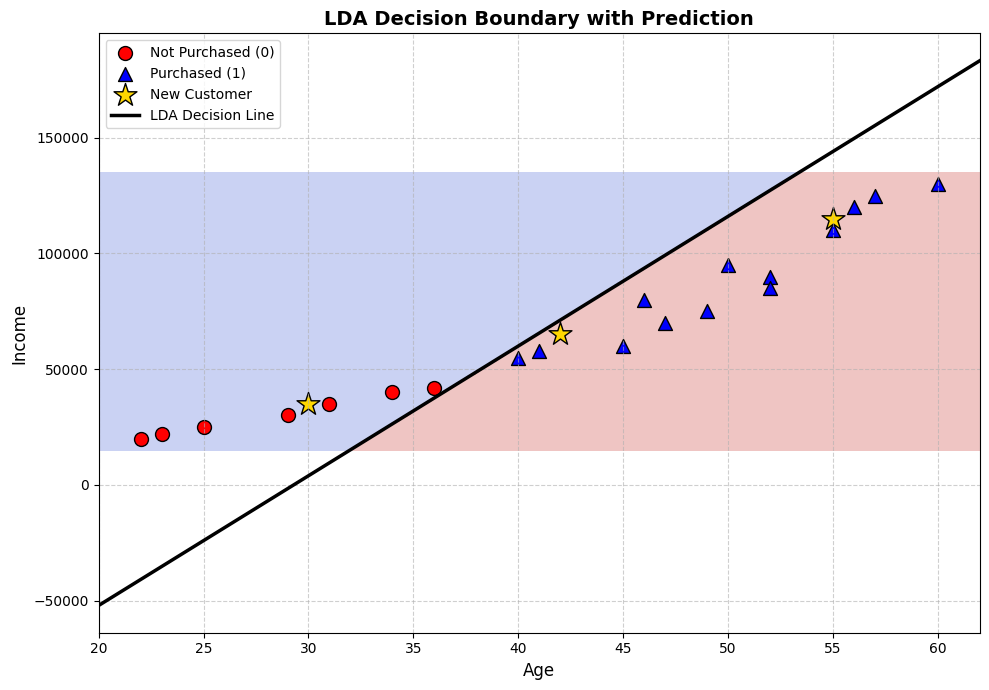

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1. สร้างข้อมูลจำลองลูกค้า
# -----------------------------
data = {
    'Age': [22, 25, 47, 52, 46, 56, 55, 60, 23, 34, 45, 52, 36, 29, 41, 57, 31, 49, 40, 50],
    'Income': [20000, 25000, 70000, 90000, 80000, 120000, 110000, 130000, 22000, 40000,
               60000, 85000, 42000, 30000, 58000, 125000, 35000, 75000, 55000, 95000],
    'Web_Visits': [5, 7, 2, 1, 2, 0, 1, 0, 5, 4, 3, 2, 4, 6, 3, 1, 4, 2, 3, 1],
    'Purchased': [0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
}
df = pd.DataFrame(data)

# -----------------------------
# 2. แบ่งข้อมูล Train/Test
# -----------------------------
X = df[['Age', 'Income']]
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 3. สร้างและฝึกโมเดล LDA
# -----------------------------
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# -----------------------------
# 4. ทำนายผลและประเมินความแม่นยำ
# -----------------------------
y_pred = lda.predict(X_test)
print("🎯 Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 5. ทำนายลูกค้าใหม่
# -----------------------------
new_customer = pd.DataFrame({
    'Age': [30, 55, 42],
    'Income': [35000, 115000, 65000]
})
prediction = lda.predict(new_customer)
print("\n🧮 New Customer Predictions:")
for i, pred in enumerate(prediction):
    label = "✅ Purchased" if pred == 1 else "❌ Not Purchased"
    print(f"Customer {i+1}: {label}")

# -----------------------------
# 6. สร้างตาราง meshgrid สำหรับกราฟ
# -----------------------------
x_min, x_max = X['Age'].min() - 2, X['Age'].max() + 2
y_min, y_max = X['Income'].min() - 5000, X['Income'].max() + 5000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -----------------------------
# 7. วาดกราฟ Decision Boundary
# -----------------------------
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# ข้อมูลจริง
plt.scatter(X['Age'][y == 0], X['Income'][y == 0],
            color='red', edgecolor='k', marker='o', s=100, label='Not Purchased (0)')
plt.scatter(X['Age'][y == 1], X['Income'][y == 1],
            color='blue', edgecolor='k', marker='^', s=100, label='Purchased (1)')

# ลูกค้าใหม่
plt.scatter(new_customer['Age'], new_customer['Income'],
            color='gold', edgecolor='black', marker='*', s=300, label='New Customer')

# เส้นจำแนก
coef = lda.coef_[0]
intercept = lda.intercept_[0]
x_vals = np.linspace(x_min, x_max, 100)
y_vals = -(coef[0] * x_vals + intercept) / coef[1]
plt.plot(x_vals, y_vals, color='black', linewidth=2.5, label='LDA Decision Line')

# -----------------------------
# 8. ตกแต่งกราฟ
# -----------------------------
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.title("LDA Decision Boundary with Prediction", fontsize=14, weight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#Ensemble Method
##Example stacking

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. สร้างข้อมูลจำลอง
data = {
    'Size': [30, 45, 60, 80, 100, 120, 150, 200, 250, 300],
    'Distance': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 5.0, 6.0, 7.0],
    'Bedrooms': [1, 1, 2, 2, 3, 3, 3, 4, 4, 5],
    'PriceClass': ['Low', 'Low', 'Medium', 'Medium', 'Medium',
                   'High', 'High', 'High', 'High', 'High']
}
df = pd.DataFrame(data)
# 2. เตรียมข้อมูล
X = df[['Size', 'Distance', 'Bedrooms']]
y = LabelEncoder().fit_transform(df['PriceClass'])  # แปลงเป็นตัวเลข

# แก้ไข: เพิ่ม stratify=y เพื่อให้การแบ่งข้อมูลคงสัดส่วนคลาส และเพิ่ม test_size เพื่อให้มีข้อมูลในทุกคลาสเพียงพอสำหรับชุดทดสอบ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# 3. สร้าง Base Models
base_models = [
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('logistic', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
]
# 4. Meta Model
meta_model = RandomForestClassifier(n_estimators=50, random_state=42)
# 5. สร้าง Stacking Model กำหนด cv=2 เนื่องจากตอนนี้ y_train มีอย่างน้อย 2 ตัวอย่างสำหรับทุกคลาสหลังจากการทำ stratify
stack_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
stack_model.fit(X_train, y_train)

# 6. ประเมินผล
y_pred = stack_model.predict(X_test)

print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

print("✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (2) does not match total number of classes (3). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (2) does not match total number of classes (3). Results may not be appropriate for your use case. To fix this, use a cross-validation technique re

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3

✅ Confusion Matrix:
[[1 0 0]
 [1 0 0]
 [0 0 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
